In [15]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('Data/train.csv')

In [4]:
df_train.head()

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
0,0,0,0,3180602.69,1,0.999812,13380276.64,NaN,NaN,0.999812,60651.50,1.000026,8493.03,1.0,-3.029704,0,0_0_0
1,1,0,0,166603.91,-1,0.999896,1642214.25,NaN,NaN,0.999896,3233.04,1.000660,20605.09,1.0,-5.519986,0,0_0_1
2,2,0,0,302879.87,-1,0.999561,1819368.03,NaN,NaN,0.999403,37956.00,1.000298,18995.00,1.0,-8.389950,0,0_0_2
3,3,0,0,11917682.27,-1,1.000171,18389745.62,NaN,NaN,0.999999,2324.90,1.000214,479032.40,1.0,-4.010200,0,0_0_3
4,4,0,0,447549.96,-1,0.999532,17860614.95,NaN,NaN,0.999394,16485.54,1.000016,434.10,1.0,-7.349849,0,0_0_4


In [5]:
df_train.columns

Index(['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size',
       'imbalance_buy_sell_flag', 'reference_price', 'matched_size',
       'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price',
       'ask_size', 'wap', 'target', 'time_id', 'row_id'],
      dtype='object')

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5237980 entries, 0 to 5237979
Data columns (total 17 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   stock_id                 int64  
 1   date_id                  int64  
 2   seconds_in_bucket        int64  
 3   imbalance_size           float64
 4   imbalance_buy_sell_flag  int64  
 5   reference_price          float64
 6   matched_size             float64
 7   far_price                float64
 8   near_price               float64
 9   bid_price                float64
 10  bid_size                 float64
 11  ask_price                float64
 12  ask_size                 float64
 13  wap                      float64
 14  target                   float64
 15  time_id                  int64  
 16  row_id                   object 
dtypes: float64(11), int64(5), object(1)
memory usage: 679.4+ MB


In [7]:
df_train.describe()

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id
count,5.237980e+06,5.237980e+06,5.237980e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237760e+06,2.343638e+06,2.380800e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237980e+06,5.237760e+06,5.237892e+06,5.237980e+06
mean,9.928856e+01,2.415100e+02,2.700000e+02,5.715293e+06,-1.189619e-02,9.999955e-01,4.510025e+07,1.001713e+00,9.996601e-01,9.997263e-01,5.181359e+04,1.000264e+00,5.357568e+04,9.999920e-01,-4.756125e-02,1.331005e+04
std,5.787176e+01,1.385319e+02,1.587451e+02,2.051591e+07,8.853374e-01,2.532497e-03,1.398413e+08,7.214705e-01,1.216920e-02,2.499345e-03,1.114214e+05,2.510042e-03,1.293554e+05,2.497509e-03,9.452860e+00,7.619271e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,9.352850e-01,4.316610e+03,7.700000e-05,7.869880e-01,9.349150e-01,0.000000e+00,9.398270e-01,0.000000e+00,9.380080e-01,-3.852898e+02,0.000000e+00
25%,4.900000e+01,1.220000e+02,1.300000e+02,8.453415e+04,-1.000000e+00,9.987630e-01,5.279575e+06,9.963320e-01,9.971000e-01,9.985290e-01,7.374720e+03,9.990290e-01,7.823700e+03,9.987810e-01,-4.559755e+00,6.729000e+03
50%,9.900000e+01,2.420000e+02,2.700000e+02,1.113604e+06,0.000000e+00,9.999670e-01,1.288264e+07,9.998830e-01,9.998890e-01,9.997280e-01,2.196900e+04,1.000207e+00,2.301792e+04,9.999970e-01,-6.020069e-02,1.334500e+04
75%,1.490000e+02,3.610000e+02,4.100000e+02,4.190951e+06,1.000000e+00,1.001174e+00,3.270013e+07,1.003318e+00,1.002590e+00,1.000905e+00,5.583168e+04,1.001414e+00,5.787841e+04,1.001149e+00,4.409552e+00,1.990700e+04
max,1.990000e+02,4.800000e+02,5.400000e+02,2.982028e+09,1.000000e+00,1.077488e+00,7.713682e+09,4.379531e+02,1.309732e+00,1.077488e+00,3.028784e+07,1.077836e+00,5.440500e+07,1.077675e+00,4.460704e+02,2.645400e+04


In [13]:
df_exp = df_train[(df_train['stock_id'] == 1) & (df_train['date_id'] == 1)]

In [14]:
df_exp

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
10506,1,1,0,648832.14,-1,0.999710,2714505.33,NaN,NaN,0.999884,517.35,1.000232,1035.06,1.000000,7.330179,55,1_0_1
10697,1,1,10,576049.80,-1,0.999884,2787287.67,NaN,NaN,0.999826,17244.00,1.000812,17261.00,1.000319,-1.360178,56,1_10_1
10888,1,1,20,527413.26,-1,0.998782,2816090.16,NaN,NaN,0.998782,9129.78,0.999594,35859.20,0.998947,11.500120,57,1_20_1
11079,1,1,30,527413.26,-1,0.998840,2816090.16,NaN,NaN,0.998782,26355.78,0.999536,45338.57,0.999060,14.779568,58,1_30_1
11270,1,1,40,522756.57,-1,0.999420,2820746.85,NaN,NaN,0.999246,1723.40,1.000696,51777.00,0.999293,5.420446,59,1_40_1
11461,1,1,50,522756.57,-1,0.999188,2820746.85,NaN,NaN,0.999188,10339.80,1.000754,17260.00,0.999775,1.579523,60,1_50_1
11652,1,1,60,522756.57,-1,0.999652,2820746.85,NaN,NaN,0.999652,2413.74,1.000638,345.16,1.000515,-5.959868,61,1_60_1
11843,1,1,70,505164.63,-1,0.999652,2838511.26,NaN,NaN,0.999652,17413.41,1.000464,17255.00,1.000060,0.109673,62,1_70_1
12034,1,1,80,524998.68,-1,0.999710,2838511.26,NaN,NaN,0.999652,17413.41,1.000116,172.49,1.000111,-3.550053,63,1_80_1
12225,1,1,90,510166.26,-1,1.000174,2853343.68,NaN,NaN,1.000000,17247.00,1.000754,4487.60,1.000598,-7.420182,64,1_90_1


## plot target distribution

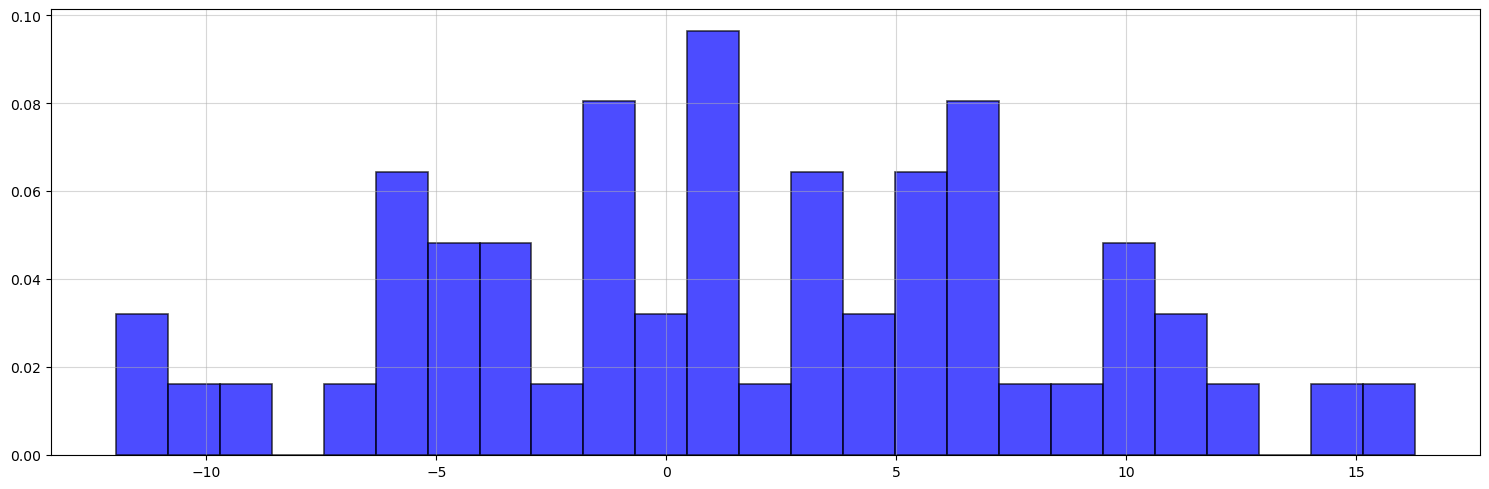

In [31]:
fig, ax = plt.subplots(figsize=(15, 5))

#plot with density=True to get the probability density function (PDF) instead of counts, 
ax.hist(df_exp['target'], density=True, bins=25, color='blue', alpha=0.7, edgecolor='black', linewidth=1.2)


ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

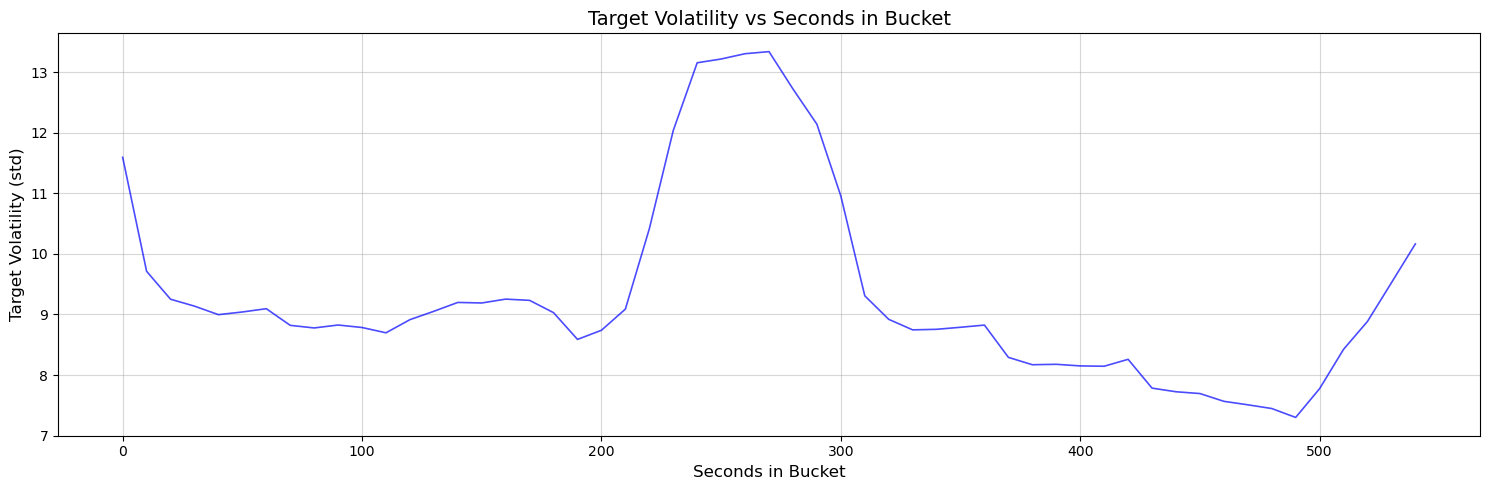

In [54]:
df_plot_vol = df_train.groupby('seconds_in_bucket')['target'].std()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_plot_vol.index, df_plot_vol.values, color='blue', alpha=0.7, linewidth=1.2)

ax.set_xlabel('Seconds in Bucket', fontsize=12)
ax.set_ylabel('Target Volatility (std)', fontsize=12)
ax.set_title('Target Volatility vs Seconds in Bucket', fontsize=14)

ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Is the cross-sectional mean of the target ≈ 0 at each time step?

In [59]:
df_train.groupby('seconds_in_bucket')['target'].agg(['mean', 'std', 'count'])

,mean,std,count
seconds_in_bucket,,,
0,-0.082055,11.595217,95232
10,0.049153,9.712804,95234
20,0.101090,9.251890,95234
30,0.130639,9.137478,95234
40,0.172697,8.996890,95234
50,0.161631,9.040893,95234
60,0.176434,9.095260,95234
70,-0.045115,8.820212,95234
80,-0.086452,8.777215,95234


Does target autocorrelate within a day? 

How many stocks, dates, and time-steps are there, and is the grid complete? 

In [39]:
print(df_train.groupby(['stock_id', 'date_id']).size().reset_index(name='counts')['counts'].value_counts())

counts
55    95236
Name: count, dtype: int64


In [45]:
print(df_train.groupby('stock_id')['date_id'].nunique().reset_index(name='counts')['counts'].value_counts())

counts
481    189
444      2
480      2
477      1
300      1
186      1
290      1
422      1
411      1
393      1
Name: count, dtype: int64


In [46]:
df_train['stock_id'].nunique()

200

What's the exact set of seconds_in_bucket values? 

In [47]:
#What's the exact set of seconds_in_bucket values? 
df_train['seconds_in_bucket'].unique()

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250,
       260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380,
       390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510,
       520, 530, 540])

Where are the NaNs, and are they structural or random?

In [48]:
df_train.isna().sum()

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                 220
imbalance_buy_sell_flag          0
reference_price                220
matched_size                   220
far_price                  2894342
near_price                 2857180
bid_price                      220
bid_size                         0
ask_price                      220
ask_size                         0
wap                            220
target                          88
time_id                          0
row_id                           0
dtype: int64

In [52]:
df_train[df_train['target'].isna()]

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
369508,131,35,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,1925,35_0_131
369700,131,35,10,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,1926,35_10_131
369892,131,35,20,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,1927,35_20_131
370084,131,35,30,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,1928,35_30_131
370276,131,35,40,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,1929,35_40_131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4225338,158,388,510,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,21391,388_510_158
4225538,158,388,520,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,21392,388_520_158
4225738,158,388,530,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,21393,388_530_158
4225938,158,388,540,NaN,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,21394,388_540_158


Does the imbalance flag actually predict the target's sign?

In [63]:
df_train.groupby('imbalance_buy_sell_flag')['target'].agg(['mean', 'std', 'count'])

,mean,std,count
imbalance_buy_sell_flag,,,
-1,-0.202263,9.231172,2084348
0,-0.062698,9.161251,1131507
1,0.120379,9.829077,2022037


Does imbalance magnitude matter?

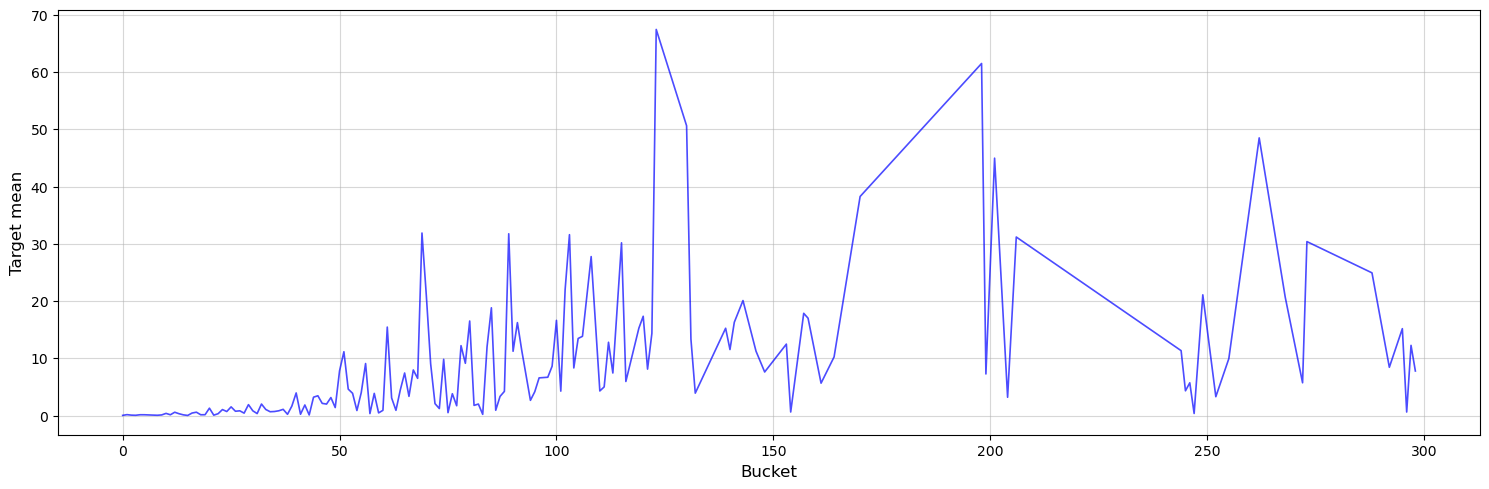

In [73]:
df_train['imbalance_bucket'] = df_train['imbalance_size'] // 10000000

df_plot = df_train[['imbalance_bucket', 'target']].groupby('imbalance_bucket').mean().reset_index()
df_plot['target'] = df_plot['target'].abs()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_plot.imbalance_bucket, df_plot.target, color='blue', alpha=0.7, linewidth=1.2)

ax.set_xlabel('Bucket', fontsize=12)
ax.set_ylabel('Target mean', fontsize=12)

ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

How does imbalance evolve through the auction? 

In [ ]:
df_auc = df_train[df_train['seconds_in_bucket'] >= 300]
df_auc.dropna(inplace=True)
df_plot = df_auc.groupby('seconds_in_bucket')['imbalance_size'].mean().reset_index()
df_plot

/var/folders/84/plrgtnrj32j1fvbb6rkrw0r00000gn/T/ipykernel_66649/4135195675.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_auc.dropna(inplace=True)


,seconds_in_bucket,imbalance_size
0,300,3.892563e+06
1,310,3.172047e+06
2,320,3.128534e+06
3,330,3.113582e+06
4,340,3.087066e+06
5,350,3.087444e+06
6,360,3.067970e+06
7,370,3.029351e+06
8,380,3.005412e+06
9,390,2.987910e+06


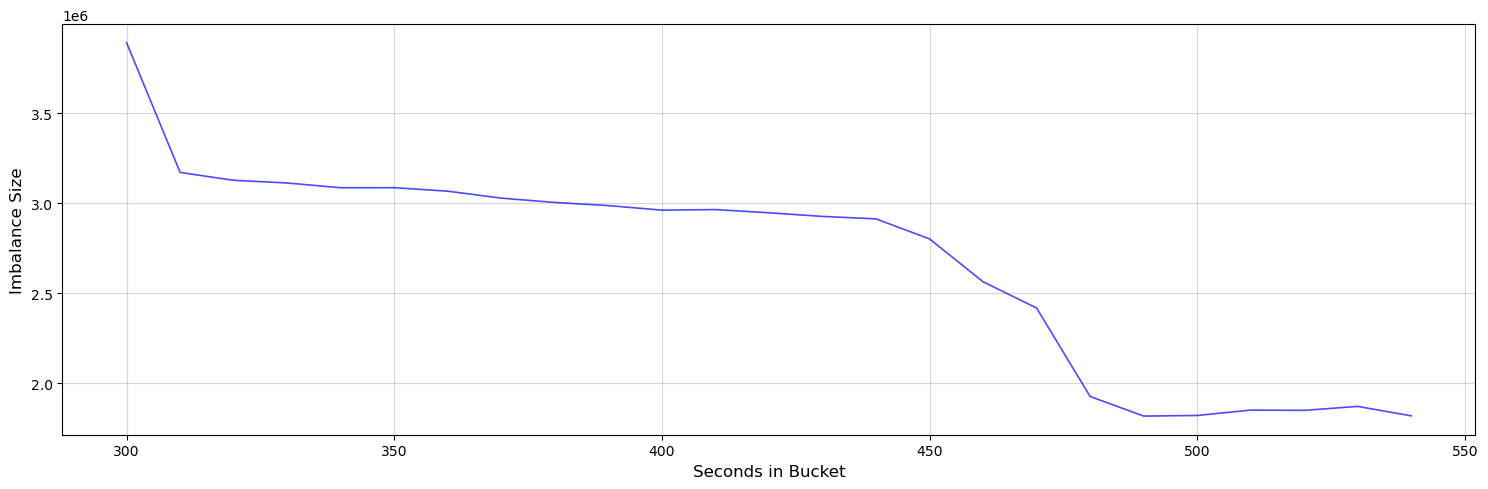

In [77]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df_plot.seconds_in_bucket, df_plot.imbalance_size, color='blue', alpha=0.7, linewidth=1.2)

ax.set_xlabel('Seconds in Bucket', fontsize=12)
ax.set_ylabel('Imbalance Size', fontsize=12)

ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

How do reference_price, near_price, far_price, and wap relate? 

In [82]:
df_late = df_train[df_train['seconds_in_bucket'] >= 300].copy()
df_late['near_minus_wap'] = (df_late['near_price'] - df_late['wap']) * 10000
df_late['far_minus_near'] = (df_late['far_price'] - df_late['near_price']) * 10000
df_late['ref_minus_wap']  = (df_late['reference_price'] - df_late['wap']) * 10000

In [87]:
df_plot = df_late.copy()
df_plot['bin'] = pd.qcut(df_plot['near_minus_wap'], q=20, duplicates='drop')
s = df_plot.groupby('bin').agg(x=('near_minus_wap', 'mean'), y=('target', 'mean')).reset_index()
s

/var/folders/84/plrgtnrj32j1fvbb6rkrw0r00000gn/T/ipykernel_66649/3768537138.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = df_plot.groupby('bin').agg(x=('near_minus_wap', 'mean'), y=('target', 'mean')).reset_index()


,bin,x,y
0,"(-1934.431, -158.971]",-302.939394,-0.417759
1,"(-158.971, -73.97]",-111.165181,-0.088873
2,"(-73.97, -31.05]",-49.375844,-0.172076
3,"(-31.05, -15.45]",-22.085132,-0.560605
4,"(-15.45, -8.81]",-11.711195,-0.732228
5,"(-8.81, -5.13]",-6.811958,-0.714468
6,"(-5.13, -2.91]",-3.921718,-0.627838
7,"(-2.91, -1.59]",-2.188916,-0.432156
8,"(-1.59, -0.75]",-1.141434,-0.164596
9,"(-0.75, -0.04]",-0.393340,0.052544


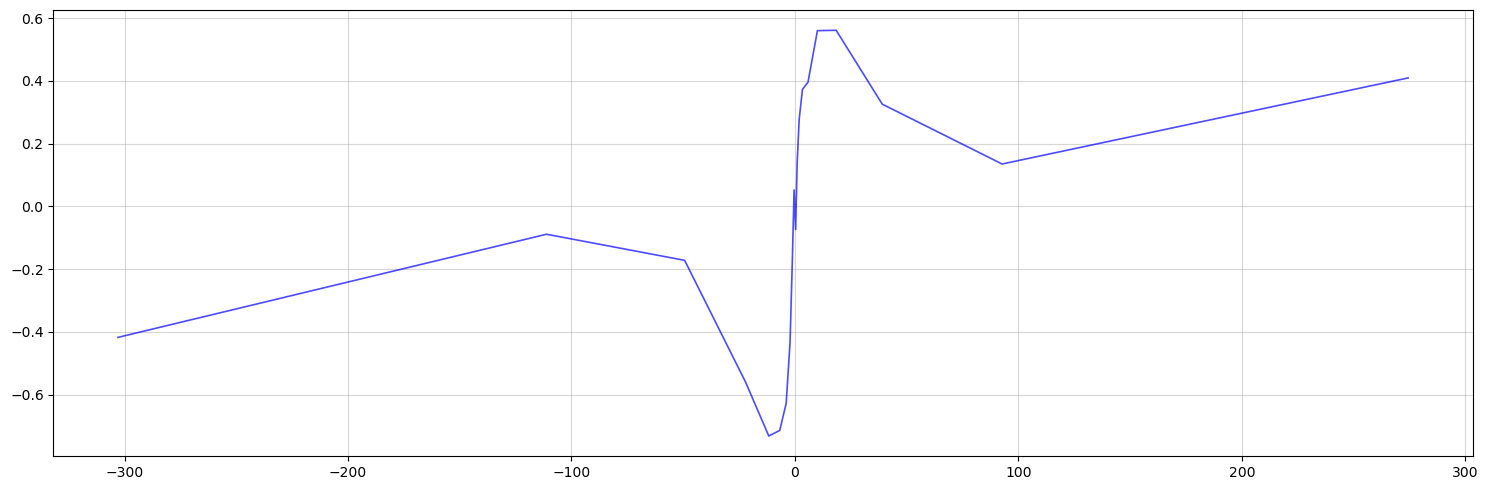

In [88]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(s.x, s.y, color='blue', alpha=0.7, linewidth=1.2)

# ax.set_xlabel('Seconds in Bucket', fontsize=12)
# ax.set_ylabel('Imbalance Size', fontsize=12)

ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

/var/folders/84/plrgtnrj32j1fvbb6rkrw0r00000gn/T/ipykernel_66649/4004934090.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s_ba = df_ba.groupby('bins').agg(x=('bid_ask_spread', 'mean'), y=('target', 'mean')).reset_index()


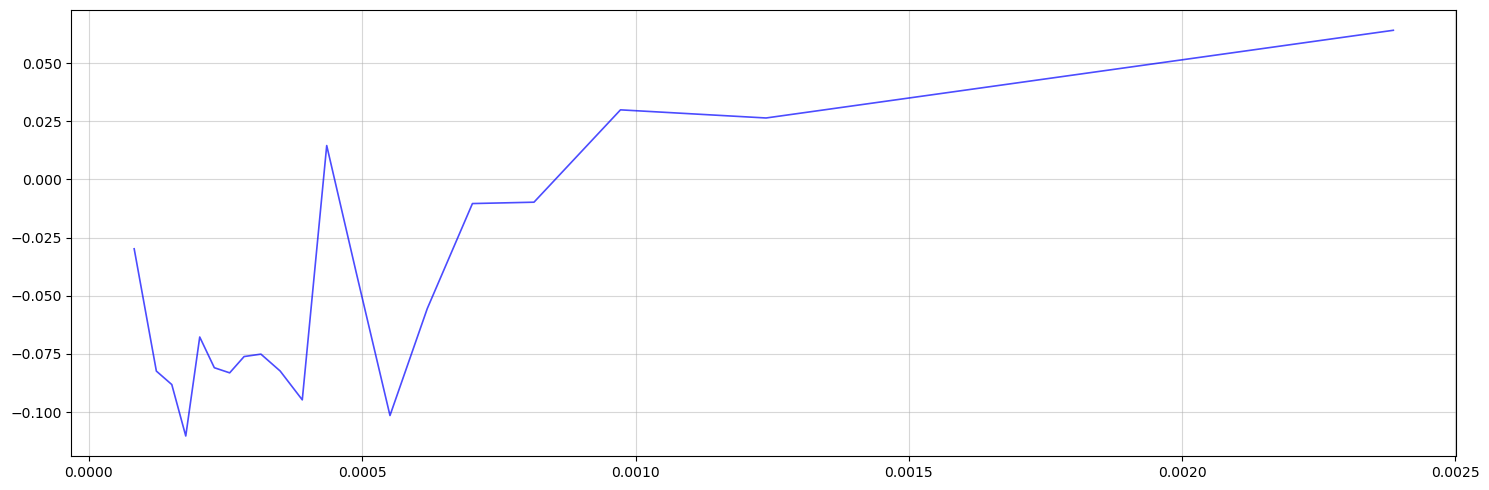

In [ ]:
df_ba = df_train.copy()
df_ba['bid_ask_spread'] = df_ba['ask_price'] - df_ba['bid_price']
df_ba.dropna(subset=['bid_ask_spread','target'], inplace=True)

df_ba['bins'] = pd.qcut(df_ba['bid_ask_spread'], q=20, duplicates='drop')
s_ba = df_ba.groupby('bins').agg(x=('bid_ask_spread', 'mean'), y=('target', 'mean')).reset_index()

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(s_ba.x, s_ba.y, color='blue', alpha=0.7, linewidth=1.2)

# ax.set_xlabel('Seconds in Bucket', fontsize=12)
# ax.set_ylabel('Imbalance Size', fontsize=12)

ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


EDA results — the full picture
Structure & integrity (data is clean and regular)

200 stocks × 481 dates, 5,237,980 rows. Every stock-day that exists has exactly 55 timesteps (seconds 0→540, every 10s). No partial auctions.
The grid isn't quite a full rectangle: 200×481 = 96,200 possible stock-days, but only 95,236 exist — some stocks simply don't trade on some days. That's normal; just don't assume every stock appears every day.
NaNs are structural, not dirty: far_price/near_price are 100% missing before 300s and ~0% missing from 300s on — confirming they only publish in the last 4 minutes. A tiny 220-row block has all book fields missing (a handful of dead auctions), and 88 targets are null. Nothing alarming.
The target (what we're predicting)

Centered at zero (mean −0.05), symmetric-ish (skew 0.2), std ≈ 9.45 bps, with fat tails (range −385 to +446).
Predict-all-zeros gives MAE = 6.41 — that's your baseline floor to beat. The gold-medal scores were ~5.40, so the entire competition lives in that 6.41 → 5.40 band (~1 bp).
Volatility rises then falls across the auction: std ≈ 11.6 at s=0, peaks ~13.3 mid-auction (~270s), drops to 10.2 at the end. The middle is the hardest, most uncertain regime.
Cross-sectional mean per timestep is ≈ 0 (ranges only −0.36 to +0.18) — confirms the "index-relative → sums to ~zero" property. A real post-processing lever later.
The signals (this is the exciting part)

Feature	Relationship to target	Strength
imbalance_buy_sell_flag	buy(+1)→mean +0.12, sell(−1)→mean −0.20	Real, modest
imbalance_ratio (signed imb / matched)	clean monotonic slope, −0.54 → +0.67	Good
near_price − wap gap	upward slope in the middle, reverts in tails	Good (non-linear)
book imbalance (bid_size vs ask_size)	strongest & cleanest: monotonic +1.9 → −2.1	Strongest raw signal
Two teaching points fall out of this table:

Book imbalance is your biggest single signal — and note it slopes negative: when resting bid size dominates, the stock tends to under-perform the index next minute. That's counter-intuitive (more buyers "should" push up), and it's a genuine microstructure effect where large resting size gets absorbed/reverts. You don't need to fully explain it — you need to use it. The clean monotonic shape means even a linear model captures it.
The auction-imbalance signals are non-linear (near−wap and imb_ratio both bend or reverse in the extremes). That's the concrete argument for why tree models beat linear ones here — a tree can carve out "normal range vs extreme" splits automatically.
Stock heterogeneity

Per-stock target std ranges 4.8 → 22.0 (median 8.1) — a 4.5× spread. Some stocks are inherently twitchier. This means stock_id itself is informative, and per-stock normalization is worth trying later.

The target is a tiny, zero-centered, fat-tailed relative return; beating MAE 6.41 is the game. The four signals we validated — book imbalance (strongest, clean, monotonic, negative slope), auction imbalance ratio, the near−wap price gap, and the imbalance flag — are all real but several are non-linear, which is why the plan goes linear-baseline → LightGBM. Data is clean and regular; the only structural quirk is that far/near prices exist only from 300s on, so features using them need a missing-value strategy.